In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import arch
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Time Series Forecasting?

**Time Series Forecasting** is the process of using a model to predict future values based on historically observed values. Unlike standard regression where data points are independent, time series data relies on the assumption that past values influence future values. The order of observations matters, and the primary predictor is often the **lagged values** of the variable itself.

For example:

* Predicting the **stock price** next week based on the last 5 years of daily closing prices.
* Predicting monthly **retail sales** in December requires knowing sales from previous months and previous Decembers.

Here is the new subsection, "Single-Step vs. Multi-Step Forecasting," to be inserted immediately after the "What is Time Series Forecasting?" section in your Jupyter Notebook outline.

## Single-Step vs. Multi-Step Forecasting

Forecasting methods are often classified based on the length of the forecast horizon, time for which the forecast is being made ($h$):

* **Single-Step Forecasting ($h=1$)**: Predicting only the **next immediate value** in the series. The forecast horizon is $h=1$. The model makes one prediction, then often stops or is reset/retrained to predict the next single step. E.g. Predicting tomorrow's temperature.

* **Multi-Step Forecasting ($h > 1$)**: Predicting a sequence of values for a future period (e.g., $Y_{t+1}, Y_{t+2}, \dots, Y_{t+h}$). For classical models, to predict $Y_{t+2}$, the model requires the value of $Y_{t+1}$, which is unknown. This is handled by two main strategies:

    | Strategy | Description | Use Case |
    | :--- | :--- | :--- |
    | **Direct** | A separate, independent model is trained for **each step** in the forecast horizon ($h$). | When the model needs to be simple and errors shouldn't compound. |
    | **Iterated (Recursive)** | The model makes a single-step forecast ($Y_{t+1}$), then uses that forecast as an **input** to predict the next step ($Y_{t+2}$), and so on. | Most common for ARIMA/AR models. Fast but subject to **error propagation** (errors compound over the horizon). |

### Data Preparation

We'll use the flight dataset from seaborn sample datasets for demonstrations in this notebook.

In [2]:
flights_df = pd.read_csv("../data/flights.csv")
flights_df.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [3]:
# Convert 'year' and 'month' columns to date string
flights_df["date"] = pd.to_datetime(
    flights_df["year"].astype(str) + "-" + flights_df["month"].astype(str) + "-01"
)

# Set the new 'date' column as the index
flights_ts = flights_df.set_index("date")["passengers"]
flights_ts.index.freq = "MS"

In [4]:
flights_ts

date
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
             ... 
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Freq: MS, Name: passengers, Length: 144, dtype: int64

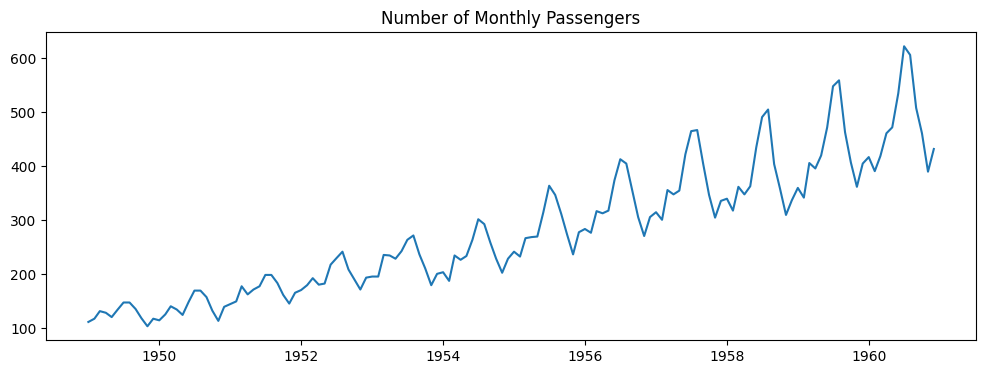

In [5]:
plt.figure(figsize=(12, 4))
plt.plot(flights_ts)
plt.title('Number of Monthly Passengers')
plt.show()

# Time Series Forecasting Models

Just like there a various ML models, there also several time series models available. Here we only be focusing on the classical approach to time series forecasting. This time series models rely on three core processes: **Autoregressive (AR)**, **Integrated (I)**, and **Moving Average (MA)**.

## Naive Models

These are simple baseline methods that are essential for evaluating the performance of complex models.

| Model | Formula | Description |
| :--- | :--- | :--- |
| **Naive** | $\hat{Y}_{t+1} = Y_t$ | The forecast is simply the **last observed value**. Best for data resembling a random walk. |
| **Seasonal Naïve** | $\hat{Y}_{t+h} = Y_{t+h-m}$ | The forecast is the value from the **same period in the previous season** ($m$). Best for strong seasonality. |
| **Simple Average** | $\hat{Y}_{t+1} = \frac{1}{t}\sum_{i=1}^t Y_i$ | The forecast is the **mean of all past observations**. Only useful for stationary data with no trend/seasonality. |

In [6]:
flights_ts.tail ()

date
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Freq: MS, Name: passengers, dtype: int64

In [7]:
# Example of Naïve Forecast
last_value = flights_ts.iloc[-1]
naive_forecast = pd.Series(
    [last_value] * 5,
    index=pd.date_range(start=flights_ts.index[-1], periods=6, freq="MS")[1:],
)
print("Naive Forecast for next 5 months:\n", naive_forecast)

Naive Forecast for next 5 months:
 1961-01-01    432
1961-02-01    432
1961-03-01    432
1961-04-01    432
1961-05-01    432
Freq: MS, dtype: int64


## AutoRegressive (AR) Model

The **AR($p$)** model uses a linear combination of the **past $p$ observations** of the variable to predict the current value. It assumes the variable is dependent on its own past values.

  * **Formula:** $Y_t = c + w_1 Y_{t-1} + w_2 Y_{t-2} + \dots + w_p Y_{t-p} + \epsilon_t$
  * **$p$:** The **order of the AR model** (the number of lagged observations to include). This is typically determined by the **PACF plot**.

<!-- end list -->

In [8]:
flights_ts.index.freq="MS"

In [9]:
# Example: AR(2) model (using 2 lagged values as predictors)
train_data = flights_ts
ar_model = AutoReg(train_data, lags=2).fit()
print(f"\nAR(2) Coefficients (w_1, w_2):\n{ar_model.params.iloc[1]:.4f}, {ar_model.params.iloc[2]:.4f}")


AR(2) Coefficients (w_1, w_2):
1.2766, -0.3298


## Moving Average (MA) Model

The **MA($q$)** model uses a linear combination of the **past $q$ forecast errors** (or residuals) to predict the current value. It assumes the variable is dependent on the random shocks in previous periods.

  * **Formula:** $Y_t = c + \epsilon_t + w_1 \epsilon_{t-1} + w_2 \epsilon_{t-2} + \dots + w_q \epsilon_{t-q}$
  * **$q$:** The **order of the MA model** (the number of lagged forecast errors to include). This is typically determined by the **ACF plot**.

## AutoRegressive Integrated Moving Average (ARIMA) Model

The **ARIMA($p, d, q$)** model is a generalized model that combines the AR and MA components and adds a crucial step: **Differencing**.

  * **AR ($p$):** The number of **Autoregressive** terms (lags of the series).
  * **I ($d$):** The number of times the raw series is **Differenced** to achieve stationarity.
  * **MA ($q$):** The number of **Moving Average** terms (lags of the forecast errors).

In [10]:
# Example: ARIMA(1, 1, 1) - One AR term, one difference, one MA term
# Note: For simplicity, we are arbitrarily choosing p, d, q here.
# In practice, 'd' is determined first, then 'p' and 'q' are found from ACF/PACF of the differenced series.

# Step 1: Fit the ARIMA model
arima_model = ARIMA(flights_ts, order=(1, 1, 1)).fit()
# Step 2: Generate the forecast
arima_forecast = arima_model.forecast(steps=5)

print("ARIMA(1, 1, 1) Forecast for next 5 months:\n", arima_forecast)

ARIMA(1, 1, 1) Forecast for next 5 months:
 1961-01-01    475.735059
1961-02-01    454.996073
1961-03-01    464.830415
1961-04-01    460.167010
1961-05-01    462.378378
Freq: MS, Name: predicted_mean, dtype: float64


## Seasonal AutoRegressive Integrated Moving Average (SARIMA) Model

The **SARIMA($p, d, q$)($P, D, Q$)\_S** model extends the non-seasonal ARIMA model by incorporating **seasonal components**. It is the standard model for time series data that exhibits clear periodicity, such as monthly sales, quarterly earnings, or daily temperatures.

The model introduces three additional seasonal terms:

| Term | Symbol | Description |
| :--- | :--- | :--- |
| **Seasonal AR** | $P$ | The number of seasonal lagged observations used in the model. |
| **Seasonal Differencing** | $D$ | The number of seasonal differencing steps required for stationarity. |
| **Seasonal MA** | $Q$ | The number of seasonal lagged forecast errors used in the model. |
| **Seasonality Period** | $S$ | The number of periods in a season (e.g., $S=12$ for monthly data, $S=4$ for quarterly data). |

In [11]:
# The order parameter is (p, d, q)
non_seasonal_order = (1, 1, 1)
# The seasonal_order parameter is (P, D, Q, S)
seasonal_order = (1, 1, 1, 12)

sarima_model = ARIMA(
    flights_ts, order=non_seasonal_order, seasonal_order=seasonal_order
).fit()

sarima_forecast = sarima_model.forecast(steps=5)

print("SARIMA Forecast for next 5 months:\n", sarima_forecast)

SARIMA Forecast for next 5 months:
 1961-01-01    449.330143
1961-02-01    424.386060
1961-03-01    459.031758
1961-04-01    497.864744
1961-05-01    509.862495
Freq: MS, Name: predicted_mean, dtype: float64


### AIC (Akaike Information Criterion) and BIC (Bayesian Information Criterion)

AIC and BIC are penalized-likelihood criteria used to find the best model structure that explains the data while avoiding overfitting. The BIC imposes a stronger penalty on models with more parameters, especially as the number of observations (N) increases. They balance the goodness of fit against the complexity (number of parameters) of the model.

AIC and BIC answer the question: "Which model structure (e.g., which combination of p,d,q for ARIMA) provides the best trade-off between fit and complexity?". With lower values indicating better model.

The AIC and BIC can be accessed via the `aic` and `bic` attributes of the models.

### Residual Analysis

A good time series model should leave behind residuals (the difference between the actual value and the forecast) that resemble **white noise**. This means the model has captured all the available predictive information.

The residual a good time series model should have the following characteristics:

* The residuals should have a **mean close to zero**.
* They should exhibit **constant variance** (homoscedasticity).
* They should have **no significant autocorrelation** (i.e., the ACF and PACF plots of the residuals should show no significant spikes outside the confidence intervals).

In [12]:
# Get residuals (y - y_pred)
residuals = arima_model.resid

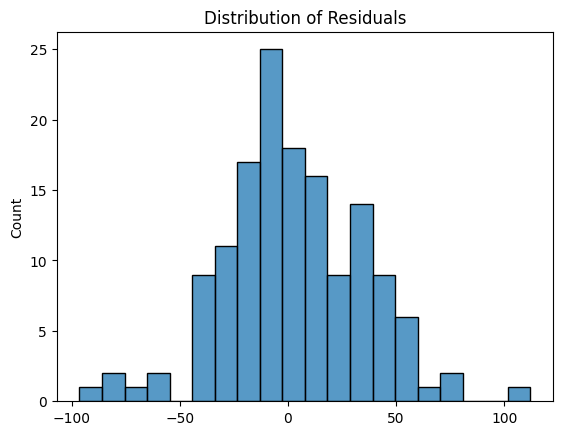

In [13]:
sns.histplot(residuals, bins=20)
plt.title("Distribution of Residuals");

In [14]:
print("Mean of Residual:", residuals.mean())

Mean of Residual: 2.7054109596486153


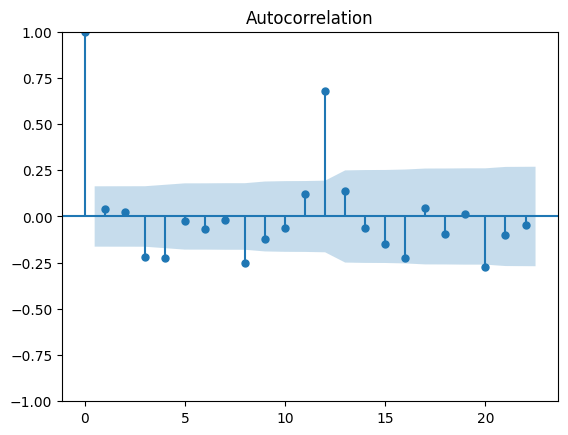

In [15]:
# Plot the ACF plot of the residual

plot_acf(residuals);

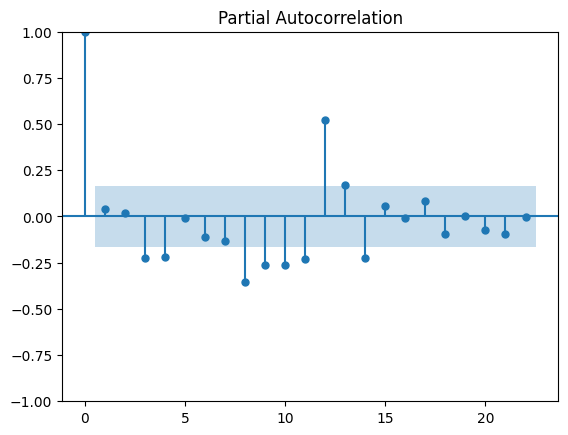

In [16]:
# Plot the PACF of the residuals

plot_pacf(residuals);

From the ACF plot, we can see that there is still some auto correlation in the residuals. Hence, we need to find the optimal values for the p, d, and/or q parameters of the model.

### Assessing Forecast Accuracy

After fitting a time series model (AR, MA, ARIMA, etc.), the next critical step is to evaluate its performance on unseen data (the test set). We could use metrics such as mean absolute error, or mean squared error like regular regression to evaluate the model.

In [17]:
# Suppose we are using the last 5 actual data points as a 'test set' for comparison.
actual_values = flights_ts.iloc[-5:].values
forecast_values = arima_forecast.values

# Ensure both arrays have the same length
N = min(len(actual_values), len(forecast_values))
actual_subset = actual_values[:N]
forecast_subset = forecast_values[:N]

rmse = np.sqrt(mean_squared_error(actual_subset, forecast_subset))

print(f"\nActual Values (Last {N} points): {actual_subset.round(2)}")
print(f"Forecast Values (Next {N} points): {forecast_subset.round(2)}")
print(f"\nRoot Mean Squared Error (RMSE): {rmse:.2f}")


Actual Values (Last 5 points): [606 508 461 390 432]
Forecast Values (Next 5 points): [475.74 455.   464.83 460.17 462.38]

Root Mean Squared Error (RMSE): 71.61


## ARCH and GARCH Models (Modeling Volatility)

These models are specifically designed to forecast the **variance** or **volatility** of a time series. They are crucial for risk management and asset pricing, especially in finance where risk is proportional to volatility. Unlike AR/MA models, they focus on the behavior of the **forecast errors** (residuals).

### ARCH Model

The **Autoregressive Conditional Heteroscedasticity (ARCH)** model assumes that the **variance** of the current error term ($\sigma_t^2$) is a function of the **squares of past error terms** ($\epsilon^2$). This captures the phenomenon of **volatility clustering**, where large price changes (large errors) tend to be followed by more large changes.

  * **Formula (ARCH($q$)):**
    $$\sigma_t^2 = \alpha_0 + \alpha_1 \epsilon_{t-1}^2 + \alpha_2 \epsilon_{t-2}^2 + \dots + \alpha_q \epsilon_{t-q}^2$$
    where:

      * $\sigma_t^2$ is the **conditional variance** (volatility) at time $t$.
      * $\epsilon_{t-i}^2$ are the **squared residuals** (past shocks) from the mean model (e.g., an ARIMA model).

  * **Example (ARCH(1)):**
    $$\sigma_t^2 = \alpha_0 + \alpha_1 \epsilon_{t-1}^2$$
    The model says that today's expected volatility ($\sigma_t^2$) is based on a constant background level ($\alpha_0$) plus the size of yesterday's unexpected movement, or shock ($\epsilon_{t-1}^2$).

### GARCH Model

The **Generalized Autoregressive Conditional Heteroscedasticity (GARCH)** model extends ARCH by allowing the conditional variance to depend not only on past squared errors but also on **past conditional variances** ($\sigma^2_{t-i}$).

  * **Formula (GARCH($p, q$)):**
    $$\sigma_t^2 = \alpha_0 + \sum_{i=1}^q \alpha_i \epsilon_{t-i}^2 + \sum_{j=1}^p \beta_j \sigma_{t-j}^2$$
    where:

      * The **ARCH terms** ($\epsilon^2_{t-i}$) capture the effect of **shocks** (news).
      * The **GARCH terms** ($\sigma^2_{t-j}$) capture the **persistence** of volatility from the previous period.

  * **Example (GARCH(1, 1)):**
    $$\sigma_t^2 = \alpha_0 + \alpha_1 \epsilon_{t-1}^2 + \beta_1 \sigma_{t-1}^2$$
    This is the most common GARCH specification. It states that today's volatility depends on:

    1.  A constant base level ($\alpha_0$).
    2.  The residual squared from the last period (the **shock effect**, $\alpha_1 \epsilon_{t-1}^2$).
    3.  The volatility forecast from the last period (the **volatility persistence**, $\beta_1 \sigma_{t-1}^2$).


To implement the models in python, we use `arch` Python library. Let's look at an example of predicting volatility of a stock indices.

In [18]:
# Load the data
dj = pd.read_csv("../data/dowjones.csv")

# Prepare the data
dj.columns = dj.columns.str.lower()
dj["date"] = pd.to_datetime(dj["date"])
dj = dj.set_index("date").squeeze()
dj.index.freq = "MS"

# Check top 5 rows
dj.head()

date
1914-12-01    55.00
1915-01-01    56.55
1915-02-01    56.00
1915-03-01    58.30
1915-04-01    66.45
Freq: MS, Name: price, dtype: float64

In [19]:
# Get monthly returns of the indices

returns = dj.pct_change().dropna()

In [20]:
# Build an ARIMA model on with the data

rets_arima_model = ARIMA(returns, order=(1, 0, 1)).fit()

In [21]:
# Get the residual

rets_resid = rets_arima_model.resid

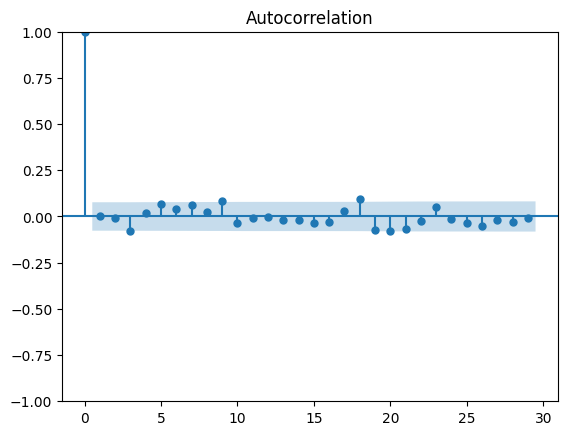

In [22]:
# Plot the ACF of residual

plot_acf(rets_resid);

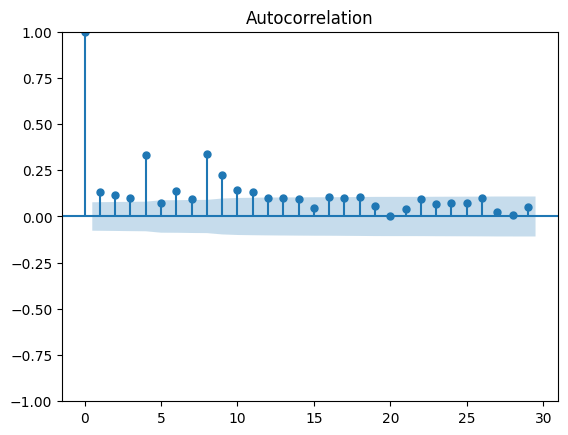

In [23]:
# Plot the ACF of the square of the residuals

plot_acf(rets_resid ** 2);

Ploting the auto correlation of the residuals helps us to determine if there is any issue of heteroskedasity (non-constant variance) in the residuals. The ACF plot shows that the residual does not have constant variance, hence we can decide to build a model to forecast variance if needed.

In [24]:
# Build GARCH(1,1) model for variance forecasting

rets_arch_model = arch.arch_model(
    rets_resid, vol="GARCH", p=1, q=1, rescale=True
).fit(disp=False)

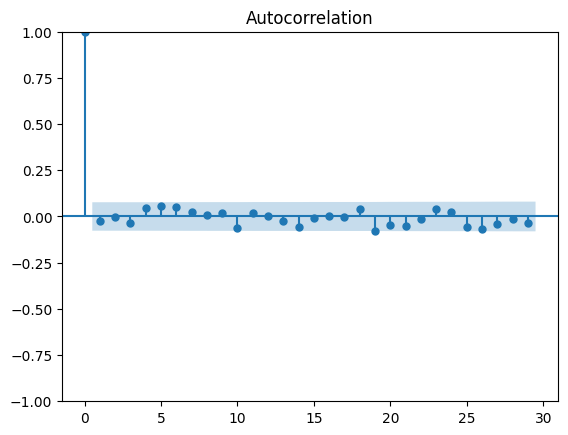

In [25]:
# Plot the standardized residual e_t/sqrt(var_t)

plot_acf(rets_arch_model.std_resid);

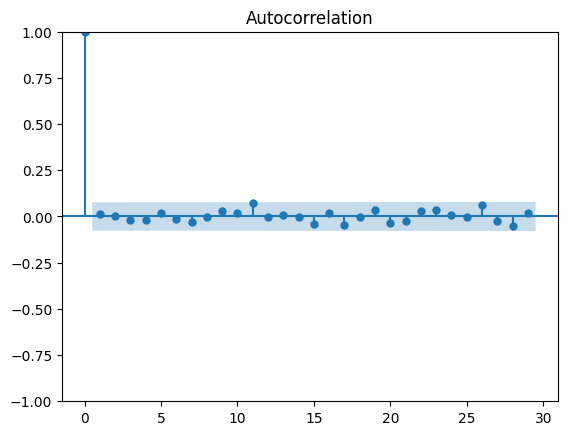

In [26]:
# Plot the square of the standardized residual

plot_acf(rets_arch_model.std_resid**2);

# Data Splitting Methods in Time Series Forecasting

Standard cross-validation (like K-Fold) is **invalid** for time series data because it breaks the temporal ordering, leading to **data leakage** (future data influencing the model trained on past data). We must use time-aware validation methods.

## Expanding Window (Growing Window)

In this method, the training set grows by including new historical data for each iteration, while the test set remains a fixed size immediately following the training data. The model is retrained from scratch at each step.

| Iteration | Training Data | Test Data |
| :--- | :--- | :--- |
| **1** | $Y_1, \dots, Y_T$ | $Y_{T+1}$ |
| **2** | $Y_1, \dots, Y_{T+1}$ | $Y_{T+2}$ |
| **3** | $Y_1, \dots, Y_{T+2}$ | $Y_{T+3}$ |

  * **Advantage:** Uses all available past data, which is theoretically best for time series forecasting.
  * **Disadvantage:** Computationally expensive as the training set size increases dramatically.

## Rolling Window (Sliding Window)

The **Rolling Window** (also known as **Walk-Forward Validation**) fixes the size of both the training set ($W$) and the test set (usually 1 or more periods, $h$). Both the training window and the test window slide forward by $h$ periods in each iteration.

| Iteration | Training Data (Window Size W) | Test Data (Forecast Horizon h) |
| :--- | :--- | :--- |
| **1** | $Y_1, \dots, Y_W$ | $Y_{W+1}, \dots, Y_{W+h}$ |
| **2** | $Y_{1+h}, \dots, Y_{W+h}$ | $Y_{W+h+1}, \dots, Y_{W+2h}$ |
| **3** | $Y_{1+2h}, \dots, Y_{W+2h}$ | $Y_{W+2h+1}, \dots, Y_{W+3h}$ |

  * **Advantage:** Keeps the training data size constant, controlling computation time and potentially discarding old data that may no longer be relevant (useful when the data structure changes over time).
  * **Disadvantage:** Discards older, potentially useful data.

### Rolling Window Implementation Example

This code demonstrates the logic for splitting data using a rolling window.

In [27]:
flights_ts.head()

date
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Freq: MS, Name: passengers, dtype: int64

In [28]:
# Assuming flights_ts is our time series data

window_size = 36 # 3 years of training data
forecast_horizon = 1 # Forecast 1 months ahead
n_observations = len(flights_ts)

# Determine the number of possible splits
n_splits = n_observations - window_size - forecast_horizon + 1

print(f"Total observations: {n_observations}")
print(f"Number of Rolling Splits: {n_splits}")
print("-" * 30)

for i in range(n_splits):
    # Define start and end indices for the train and test sets
    train_start_idx = i
    train_end_idx = i + window_size
    test_end_idx = train_end_idx + forecast_horizon

    # Get the subsets
    train = flights_ts.iloc[train_start_idx:train_end_idx]
    test = flights_ts.iloc[train_end_idx:test_end_idx]

    # Print the dates to show the rolling action
    print(f"Split {i+1}: Train Range: {train.index.min().date()} to {train.index.max().date()}")
    print(f"Test Range: {test.index.min().date()} to {test.index.max().date()}")

    if i == 1:
        # Stop after 2 splits for brevity
        break

Total observations: 144
Number of Rolling Splits: 108
------------------------------
Split 1: Train Range: 1949-01-01 to 1951-12-01
Test Range: 1952-01-01 to 1952-01-01
Split 2: Train Range: 1949-02-01 to 1952-01-01
Test Range: 1952-02-01 to 1952-02-01


Let's look at an example. Evaluting the previos ARIMA(1,1,1) model. We will use the first 12 months of the flights passengers time series as the training and more data to the training until prediction has been made for all the outer samples.

--- Expanding Window Forecast Results ---
RMSE (Last 36 Months): 47.17


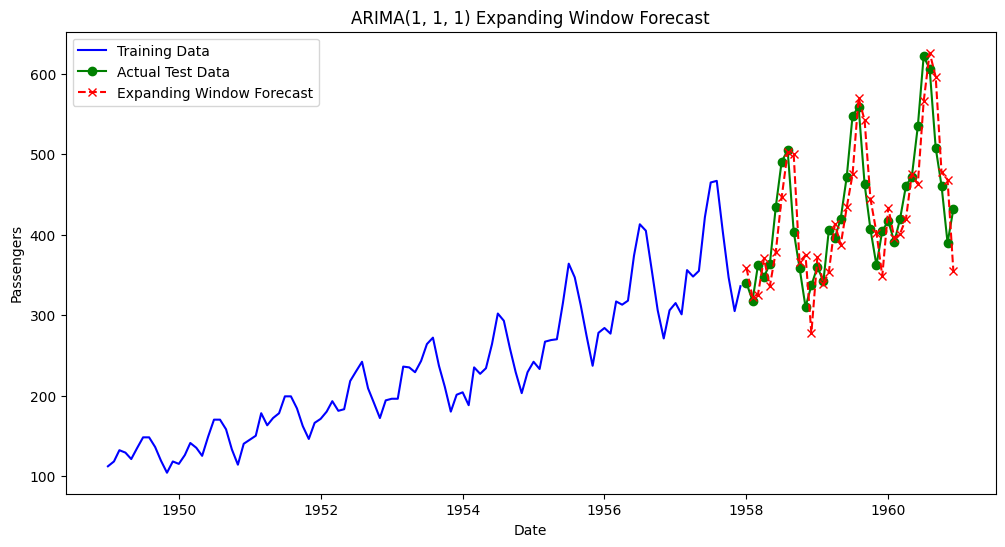

In [29]:
# 1. Define Training and Testing Sizes
# Total length of the data is 144 months (12 years)
data_length = len(flights_ts)
test_size = 3 * 12  # Forecast the last 3 years
train_size = data_length - test_size

# 2. Split the data
train_data = flights_ts.iloc[:train_size]
test_data = flights_ts.iloc[train_size:]

# 3. Initialize lists for storing forecasts and actuals
forecasts = []
actuals = []

# 4. Perform Expanding Window Walk-Forward Validation
for t in range(test_size):
    # The training data expands by one step each iteration
    end_of_train_index = train_size + t
    current_train = flights_ts.iloc[:end_of_train_index]

    # Define the ARIMA model on the current training window
    # Note: Model order is typically fixed after selection (e.g., via AIC/BIC)
    model = ARIMA(current_train, order=(1, 1, 1))
    model_fit = model.fit()

    # Generate a one-step-ahead forecast
    one_step_forecast = model_fit.forecast(steps=1)

    # Store results
    forecasts.append(one_step_forecast.iloc[0])
    actuals.append(test_data.iloc[t])

# 5. Calculate Final RMSE
forecasts_series = pd.Series(forecasts, index=test_data.index)
rmse_expanding_window = np.sqrt(mean_squared_error(actuals, forecasts))

print("--- Expanding Window Forecast Results ---")
print(f"RMSE (Last {test_size} Months): {rmse_expanding_window:.2f}")

# 6. Plot the results
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data, label="Training Data", color="blue")
plt.plot(
    test_data.index, test_data, label="Actual Test Data", color="green", marker="o"
)
plt.plot(
    forecasts_series.index,
    forecasts_series,
    label="Expanding Window Forecast",
    color="red",
    linestyle="--",
    marker="x",
)
plt.title("ARIMA(1, 1, 1) Expanding Window Forecast")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.show()

# Time Series Forecasting with Machine Learning

Forecasting with ML models like Linear Regression, Random Forest, or Neural Networks involves reframing the problem from predicting $Y_t$ based on $Y_{t-1}$ to predicting $Y_t$ based on a vector of **engineered features** ($X$). This can either be inform of classification or regression.

## Time Series Regression and Classification

  * **Time Series Regression (Forecasting):** Predicting a continuous, future value ($\hat{Y}_{t+h}$) based on past observations and engineered features. This is the primary focus of this notebook.
      * *Example:* Predicting the *number* of passengers next month.
  * **Time Series Classification:** Predicting a categorical outcome based on the entire sequence of a time series.
      * *Example:* Classifying a stock price series as "bullish" or "bearish."

## Time Series Forecasting vs Time Series Regression

| Feature | Classical Time Series (ARIMA) | Machine Learning Regression |
| :--- | :--- | :--- |
| **Input Data** | Dependent variable ($Y$) is the only input; uses lagged $Y$ values and lagged errors. | Requires **feature matrix** ($X$) and target vector ($Y$); time itself is a feature. |
| **Stationarity** | **Strict requirement.** Data must be made stationary (differencing) for valid inference. | **Less strict.** Models can learn non-linear trends and seasonality directly from engineered features. |
| **Model** | Equation-based, focused on correlation/covariance structure (ACF/PACF). | Algorithm-based, focused on mapping inputs ($X$) to output ($Y$). |

# Time Series Feature Engineering

To use standard ML models for forecasting, we must transform the time index into meaningful numerical features that capture **trend** and **seasonality**.

## Trend Features

Trend is captured by adding a monotonic variable that increases with time.

In [30]:
# Feature 1: Numerical time step (index)
df_features = pd.DataFrame(index=flights_ts.index)
df_features["trend"] = np.arange(len(flights_ts)) + 1
print("Trend Features:")
print(df_features.head())

Trend Features:
            trend
date             
1949-01-01      1
1949-02-01      2
1949-03-01      3
1949-04-01      4
1949-05-01      5


## Seasonal Features

Seasonality (e.g., monthly patterns) can be captured using categorical encoding or trigonometric transformations.

In [31]:
# Create seasonal features using one-hot encoding for the month
df_features["month"] = df_features.index.month.astype(str)
df_features = pd.get_dummies(df_features, columns=["month"]).astype(int)
print(f"Seasonal features added. Total columns: {df_features.shape[1]}")

Seasonal features added. Total columns: 13


In [32]:
df_features.head()

,trend,month_1,month_10,month_11,month_12,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9
date,,,,,,,,,,,,,
1949-01-01,1,1,0,0,0,0,0,0,0,0,0,0,0
1949-02-01,2,0,0,0,0,1,0,0,0,0,0,0,0
1949-03-01,3,0,0,0,0,0,1,0,0,0,0,0,0
1949-04-01,4,0,0,0,0,0,0,1,0,0,0,0,0
1949-05-01,5,0,0,0,0,0,0,0,1,0,0,0,0


### Lag Features

Lag features (or autoregressive features) are the most important features in time series ML. They directly incorporate the time-dependent relationship of a series by making past values of the target variable available as predictors for the current value.

In [33]:
# Create Lag 1 and Lag 12 features
df_features["lag_1"] = flights_ts.shift(1)
df_features["lag_2"] = flights_ts.shift(2)

# Drop the first 12 rows which now contain NaN due to the lags
df_features.dropna(inplace=True)

print("Lag features added and NaN rows removed.")
print(f"Remaining data length: {len(df_features)}")

Lag features added and NaN rows removed.
Remaining data length: 142


In [34]:
df_features.head()

,trend,month_1,month_10,month_11,month_12,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,lag_1,lag_2
date,,,,,,,,,,,,,,,
1949-03-01,3,0,0,0,0,0,1,0,0,0,0,0,0,118.0,112.0
1949-04-01,4,0,0,0,0,0,0,1,0,0,0,0,0,132.0,118.0
1949-05-01,5,0,0,0,0,0,0,0,1,0,0,0,0,129.0,132.0
1949-06-01,6,0,0,0,0,0,0,0,0,1,0,0,0,121.0,129.0
1949-07-01,7,0,0,0,0,0,0,0,0,0,1,0,0,135.0,121.0


### Fourier Features

Fourier Features are sets of features derived from the [Fourier series](https://en.wikipedia.org/wiki/Fourier_series) terms that represent periodic (seasonal) components of the time series. They are a pair of sine and cosine functions used to represent seasonality, requiring fewer parameters than one-hot encoding for long seasonal periods. 

The formula for calculating Fourier Features in time series analysis for a given seasonal period $sp$ is:

$$ sin\_sp\_k = sin\big(\frac{2\pi kt}{sp}\big)$$
$$ cos\_sp\_k = cos\big(\frac{2\pi kt}{sp}\big)$$

Where:

* $t$ is the elapsed time (e.g., time index),
* $sp$ is the length of the seasonal period,
* $k$ represents the $k$-th Fourier term (an integer from 1 to the number of terms used), which is also the number of times the pattern occurs in the seasonal period.

Suppose we have a times series of daily data with annual frequencies that occur four times in a year. Then we would need 4 fourier pairs (8 features) to capture the pattern in our model.

In [35]:
from statsmodels.tsa.deterministic import Fourier

In [36]:
fourier = Fourier(period=12, order=4)

In [37]:
fourier_feats = fourier.in_sample(flights_ts.index)
fourier_feats.head()

,"sin(1,12)","cos(1,12)","sin(2,12)","cos(2,12)","sin(3,12)","cos(3,12)","sin(4,12)","cos(4,12)"
date,,,,,,,,
1949-01-01,0.000000,1.000000e+00,0.000000e+00,1.0,0.000000e+00,1.000000e+00,0.000000e+00,1.0
1949-02-01,0.500000,8.660254e-01,8.660254e-01,0.5,1.000000e+00,6.123234e-17,8.660254e-01,-0.5
1949-03-01,0.866025,5.000000e-01,8.660254e-01,-0.5,1.224647e-16,-1.000000e+00,-8.660254e-01,-0.5
1949-04-01,1.000000,6.123234e-17,1.224647e-16,-1.0,-1.000000e+00,-1.836970e-16,-2.449294e-16,1.0
1949-05-01,0.866025,-5.000000e-01,-8.660254e-01,-0.5,-2.449294e-16,1.000000e+00,8.660254e-01,-0.5


In [38]:
fourier_feats.tail()

,"sin(1,12)","cos(1,12)","sin(2,12)","cos(2,12)","sin(3,12)","cos(3,12)","sin(4,12)","cos(4,12)"
date,,,,,,,,
1960-08-01,-0.500000,-8.660254e-01,8.660254e-01,0.5,-1.000000e+00,-1.028765e-14,8.660254e-01,-0.5
1960-09-01,-0.866025,-5.000000e-01,8.660254e-01,-0.5,-1.567795e-14,1.000000e+00,-8.660254e-01,-0.5
1960-10-01,-1.000000,2.451151e-15,-4.902301e-15,-1.0,1.000000e+00,-7.353452e-15,9.804602e-15,1.0
1960-11-01,-0.866025,5.000000e-01,-8.660254e-01,-0.5,-3.038486e-14,-1.000000e+00,8.660254e-01,-0.5
1960-12-01,-0.500000,8.660254e-01,-8.660254e-01,0.5,-1.000000e+00,-3.184886e-14,-8.660254e-01,-0.5


In [39]:
fourier.out_of_sample(steps=2, index = flights_ts.index)

,"sin(1,12)","cos(1,12)","sin(2,12)","cos(2,12)","sin(3,12)","cos(3,12)","sin(4,12)","cos(4,12)"
1961-01-01,-2.939152e-15,1.000000,-5.878305e-15,1.0,-8.817457e-15,1.000000e+00,-1.175661e-14,1.0
1961-02-01,5.000000e-01,0.866025,8.660254e-01,0.5,1.000000e+00,-1.421395e-14,8.660254e-01,-0.5


### Choosing the Number (Order) of Fourier Features

The number of Fourier pairs (sine and cosine terms) to use for time series analysis or forecasting is typically chosen based on the complexity of the seasonal or periodic patterns you want to capture and the length of the seasonal period.

A common practical approach is to start with a small number of Fourier pairs and increase gradually, validated by model performance metrics (e.g., cross-validation, out-of-sample error).

An alternative approach is to use a [periodogram](https://en.wikipedia.org/wiki/Periodogram) or [spectral density estimate](https://en.wikipedia.org/wiki/Spectral_density_estimation) of the series to guide selection by identifying dominant frequencies to include in the Fourier features.

We can compute the spectral density estimates by using the `periodogram` function available in `scipy` library.

In [40]:
from scipy.signal import periodogram

In [41]:
freqencies, spectrum = periodogram(
    flights_ts, fs=12.0, detrend="linear", scaling="spectrum"
)

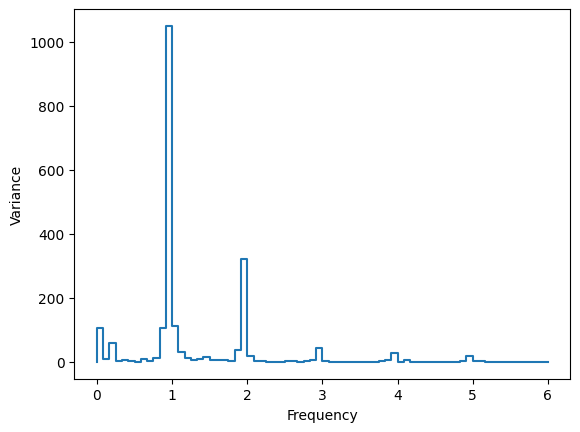

In [42]:
fig = plt.figure()
ax = fig.add_subplot()
ax.step(freqencies, spectrum)
ax.set_ylabel("Variance")
ax.set_xlabel("Frequency");

The periodogram shows us that there is a strong annual pattern that occurs once per year. And another annual but weaker pattern that occurs twice per year. In practice, we pick the last frequency (2) just before the variance drops off. The frequency chosen will determine the number of fourier pairs, $k$ to generate as seasonal features.

# Forecasting with Scikit-Learn

We now transform the time series into a supervised learning problem using the engineered features and a standard `scikit-learn` regressor.

We will use a simple **Linear Regression** model to forecast passengers, employing the **Expanding Window** technique for model training and evaluation.

### Data Split for Expanding Window

We manually split the data, holding out the final **24 months (2 years)** for out-of-sample evaluation.

Train size: 106 | Test size: 36

RMSE for Linear Regression (Expanding Window): 25.30


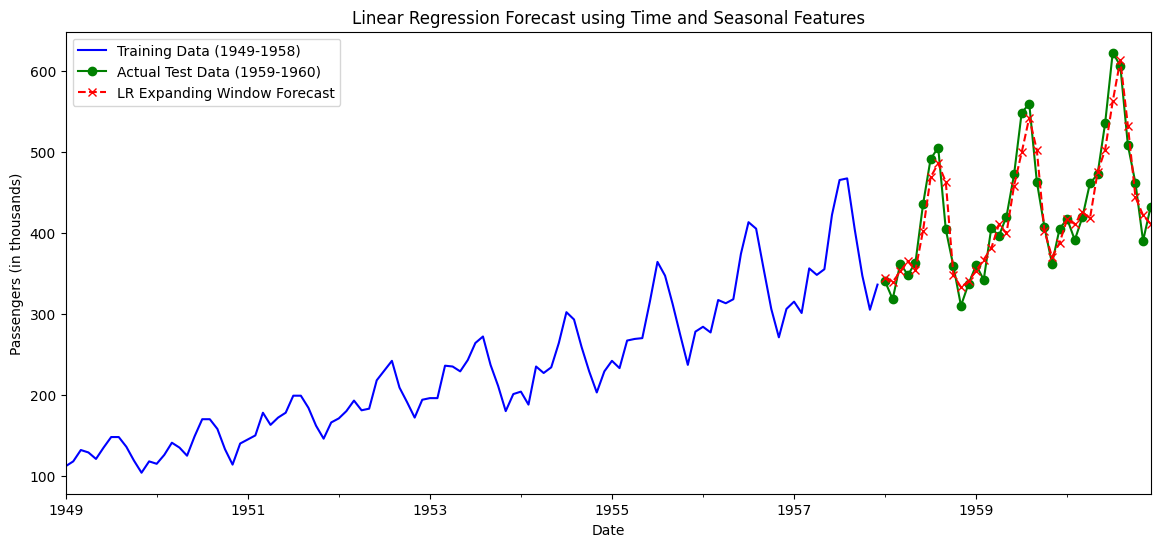

In [43]:
# Split data: Train on first 120 months (1949-1958), Test on last 24 months (1959-1960)
X = df_features
y_target = flights_ts.loc[X.index]
test_size = 36

X_train = X.iloc[:-test_size]
X_test = X.iloc[-test_size:]
y_train = y_target.iloc[:-test_size]
y_test = y_target.iloc[-test_size:]

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

# Initialize the model and forecast storage
model = LinearRegression()
forecasts_lr = []
actuals_lr = y_test.tolist()  # Actual test values

# Perform Expanding Window Walk-Forward Validation
for t in range(test_size):
    # Training window expands each time
    X_current_train = pd.concat([X_train, X_test.iloc[:t]])
    y_current_train = pd.concat([y_train, y_test.iloc[:t]])

    # Target feature for one-step forecast
    X_target = X_test.iloc[t : t + 1]

    # 1. Fit the model
    model.fit(X_current_train, y_current_train)

    # 2. Predict one step ahead
    y_pred = model.predict(X_target)

    # 3. Store the forecast
    forecasts_lr.append(y_pred[0])

# Evaluation
forecasts_series_lr = pd.Series(forecasts_lr, index=y_test.index)
rmse_lr = np.sqrt(mean_squared_error(y_test, forecasts_series_lr))

print(f"\nRMSE for Linear Regression (Expanding Window): {rmse_lr:.2f}")

# Plotting the result
plt.figure(figsize=(14, 6))
flights_ts.iloc[:-test_size].plot(label="Training Data (1949-1958)", color="blue")
y_test.plot(label="Actual Test Data (1959-1960)", color="green", marker="o")
forecasts_series_lr.plot(
    label="LR Expanding Window Forecast", color="red", linestyle="--", marker="x"
)
plt.title("Linear Regression Forecast using Time and Seasonal Features")
plt.xlabel("Date")
plt.ylabel("Passengers (in thousands)")
plt.legend()
plt.show()

# Hybrid Forecasting Models

Hybrid models combine strengths of different approaches, often leveraging a linear model to capture trend/seasonality and a non-linear model to capture the complex, remaining relationship in the residuals.

## Linear Regression and Decision Tree Hybrid Model

A simple hybrid strategy is to:

1.  Use **Linear Regression** to model the overall **trend and seasonality** (linear components).
2.  Analyze the **residuals** of the Linear Regression model.
3.  Use a **Decision Tree** (or other non-linear model) to model the remaining, complex, and potentially **non-linear patterns** in those residuals.
4.  The final forecast is the sum of the Linear Regression forecast and the Decision Tree forecast of the residuals.

In [44]:
from sklearn.ensemble import GradientBoostingRegressor

Train size: 106 | Test size: 36

RMSE for Hybrid Model (Expanding Window): 27.04


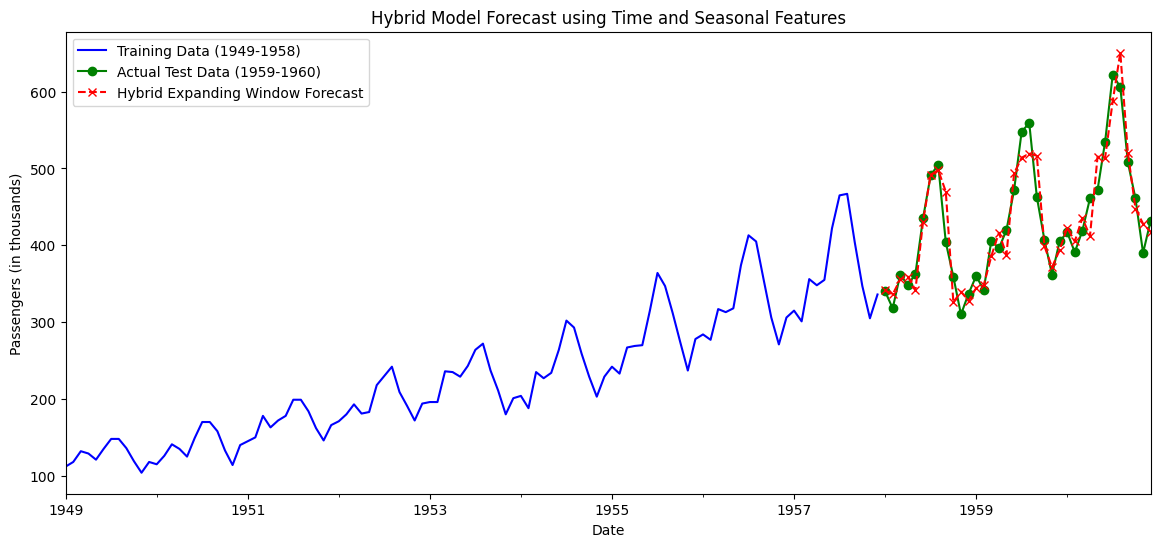

In [45]:
# Split data: Train on first 120 months (1949-1958), Test on last 24 months (1959-1960)
X = df_features
y_target = flights_ts.loc[X.index]
test_size = 36

X_train = X.iloc[:-test_size]
X_test = X.iloc[-test_size:]
y_train = y_target.iloc[:-test_size]
y_test = y_target.iloc[-test_size:]

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

# Initialize the model and forecast storage
lr_model = LinearRegression()
gb_model = GradientBoostingRegressor(random_state=42)
forecasts_hybrid = []
actuals_lr = y_test.tolist()  # Actual test values

# Perform Expanding Window Walk-Forward Validation
for t in range(test_size):
    # Training window expands each time
    X_current_train = pd.concat([X_train, X_test.iloc[:t]])
    y_current_train = pd.concat([y_train, y_test.iloc[:t]])

    # Target feature for one-step forecast
    X_target = X_test.iloc[t : t + 1]

    # Model trend and seasonality, and get predictions
    lr_model.fit(X_current_train, y_current_train)
    y_trend_season_train_pred = lr_model.predict(X_current_train)
    y_trend_season_test_pred = lr_model.predict(X_target)

    # Get residuals
    residuals_train = y_current_train - y_trend_season_train_pred

    # Model residual (Non-linear/Cyclic) component with Decision Tree
    gb_model.fit(X_current_train, residuals_train)

    # Predict Residual Component for the test period
    y_residual_test_pred = gb_model.predict(X_target)

    # Combine the two components
    y_hybrid_pred = y_trend_season_test_pred + y_residual_test_pred
    forecasts_hybrid.append(y_hybrid_pred[0])

# Evaluation
forecasts_series_hybrid = pd.Series(forecasts_hybrid, index=y_test.index)
rmse_lr = np.sqrt(mean_squared_error(y_test, forecasts_series_hybrid))

print(f"\nRMSE for Hybrid Model (Expanding Window): {rmse_lr:.2f}")

# Plotting the result
plt.figure(figsize=(14, 6))
flights_ts.iloc[:-test_size].plot(label="Training Data (1949-1958)", color="blue")
y_test.plot(label="Actual Test Data (1959-1960)", color="green", marker="o")
forecasts_series_hybrid.plot(
    label="Hybrid Expanding Window Forecast", color="red", linestyle="--", marker="x"
)
plt.title("Hybrid Model Forecast using Time and Seasonal Features")
plt.xlabel("Date")
plt.ylabel("Passengers (in thousands)")
plt.legend()
plt.show()

## Hierarchical and Grouped Time Series Forecasting 

In many business applications, time series data is naturally organized into nested structures (hierarchies) or parallel groups. Forecasting these interrelated series requires specialized methods to ensure consistency and improve accuracy.

### Hierarchical Forecasting?

**Hierarchical Forecasting** deals with data that can be naturally aggregated up a defined tree-like structure. The forecasts at lower levels must sum up exactly to the forecasts at the higher, aggregated levels. This crucial requirement is known as **coherency** or **summing consistency**.

#### Example: Retail Sales Hierarchy

| Level | Description | Example |
| :--- | :--- | :--- |
| **Top (Root)** | Total Company Sales | Total Sales |
| **Middle** | Product Category Sales | Electronics, Clothing, Groceries |
| **Bottom (Base)** | Individual Product Sales | iPhone 15, Denim Jacket, Organic Apples |

Forecasting the individual product sales (bottom level) and then ensuring they sum up to the total company sales (top level) is the challenge of hierarchical forecasting.

### Grouped Forecasting?

**Grouped Forecasting** is a generalization of hierarchical forecasting where the time series can be grouped in **multiple, intersecting ways**. The series do not necessarily form a strict tree structure, but the totals within each group still need to be consistent.

#### Example: Sales Grouped by Location and Channel

A single product's sales data could be grouped by:

1.  **Location Group:** Sum of sales across all US states, total sales in Europe.
2.  **Channel Group:** Total sales from the Website, total sales from Retail Stores.

A single sale must be accounted for in both the US total and the Website total, leading to complex reconciliation requirements.

## Modeling Strategies

When dealing with many related time series, there are two primary modeling strategies:

| Strategy | Local (Bottom-Up) Models | Global (Top-Down/Pooled) Models |
| :--- | :--- | :--- |
| **Definition** | A separate model is trained for **each individual time series** (e.g., one model per product). | A **single model** is trained on the pooled data from *all* time series, using the series ID as a categorical feature. |
| **Pros** | Captures unique, idiosyncratic patterns for each series. Generally flexible. | Efficient for large numbers of series. Allows information sharing (transfer learning) between series. |
| **Cons** | Computationally expensive and slow. Prone to instability/overfitting on short or noisy series. | May miss unique patterns. Assumes the relationship between predictors and the target is the same across all series. |